# 01 — Explore and Validate the Dataset

This notebook has one job: make sure the dataset is clean, balanced, and ready
for fine-tuning before a single training step runs.

Outputs written to `data/processed/`:
- `train.csv` — 80% of each class
- `val.csv`   — 10% of each class
- `test.csv`  — 10% of each class (do not look at this until notebook 03)

**Gate:** do not run notebook 02 until every check in this notebook passes.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

RAW_PATH = Path('../data/raw/queries.csv')
PROC_DIR = Path('../data/processed')
PROC_DIR.mkdir(parents=True, exist_ok=True)

INTENT_CLASSES = ['news', 'factual', 'code', 'research', 'commercial', 'general']
MIN_PER_CLASS = 200
RANDOM_SEED = 42

Matplotlib is building the font cache; this may take a moment.


## 1. Load and inspect the raw dataset

In [3]:
df = pd.read_csv(RAW_PATH)

print(f'Total rows: {len(df)}')
print(f'Columns:{df.columns.tolist()}')
print()
df.head(10)

Total rows: 1268
Columns:['query', 'intent']



,query,intent
0,kenya election results today,news
1,breaking news nairobi,news
2,premier league scores this weekend,news
3,latest developments in the region,news
4,what happened in parliament yesterday,news
5,stock market close today,news
6,new product launch announcement,news
7,government budget news,news
8,africa cup of nations results,news
9,weather forecast tomorrow,news


## 2. Schema validation

In [4]:
errors = []

if 'query' not in df.columns:
    errors.append('FAIL missing column: query')
if 'intent' not in df.columns:
    errors.append('FAIL missing column: intent')

null_queries = df['query'].isnull().sum()
null_intents = df['intent'].isnull().sum()
if null_queries > 0:
    errors.append(f'FAIL {null_queries} null values in query column')
if null_intents > 0:
    errors.append(f'FAIL {null_intents} null values in intent column')

unknown_classes = set(df['intent'].unique()) - set(INTENT_CLASSES)
if unknown_classes:
    errors.append(f'FAIL unknown intent classes found: {unknown_classes}')

duplicates = df.duplicated(subset=['query']).sum()
if duplicates > 0:
    errors.append(f'FAIL {duplicates} duplicate queries found')

if errors:
    for e in errors:
        print(e)
    raise ValueError('Dataset failed schema validation. Fix errors above before continuing.')
else:
    print('PASS schema validation — no errors')

PASS schema validation — no errors


## 3. Class distribution

In [5]:
counts = df['intent'].value_counts().reindex(INTENT_CLASSES)
print('Examples per class:')
print(counts.to_string())
print()

below_minimum = counts[counts < MIN_PER_CLASS]
if len(below_minimum) > 0:
    print('FAIL  the following classes are below the minimum threshold:')
    print(below_minimum.to_string())
    print(f'\nAdd more examples to reach {MIN_PER_CLASS} per class and rerun this notebook.')
    raise ValueError('Insufficient examples per class.')
else:
    print(f'PASS  all classes meet the minimum of {MIN_PER_CLASS} examples')

Examples per class:
intent
news          205
factual       201
code          231
research      221
commercial    201
general       209

PASS  all classes meet the minimum of 200 examples


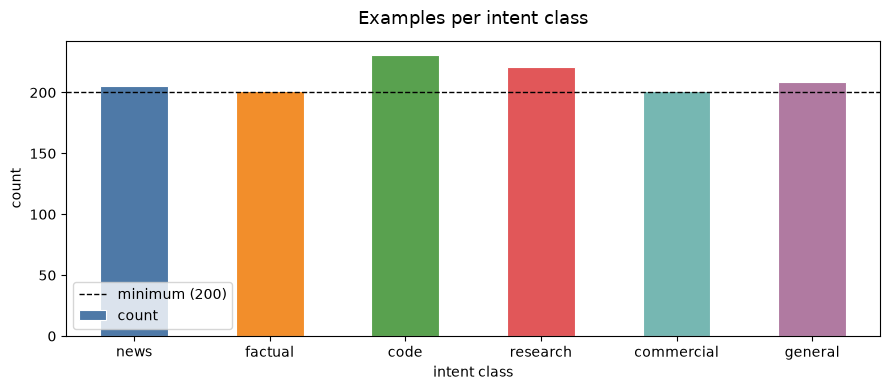

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759', '#76b7b2', '#b07aa1']
counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(MIN_PER_CLASS, color='black', linestyle='--', linewidth=1, label=f'minimum ({MIN_PER_CLASS})')
ax.set_title('Examples per intent class', fontsize=13, pad=12)
ax.set_xlabel('intent class')
ax.set_ylabel('count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Query length distribution

In [7]:
df['query_length'] = df['query'].str.split().str.len()

length_stats = df.groupby('intent')['query_length'].describe()[['min', '50%', 'max', 'mean']]
length_stats.columns = ['min_words', 'median_words', 'max_words', 'mean_words']
length_stats = length_stats.round(1)
print('Query word count per class:')
print(length_stats.to_string())

Query word count per class:
            min_words  median_words  max_words  mean_words
intent                                                    
code              2.0           3.0        9.0         3.4
commercial        3.0           4.0        8.0         4.3
factual           3.0           6.0        9.0         5.5
general           3.0           5.0        9.0         5.3
news              2.0           3.0        5.0         3.5
research          2.0           5.0        7.0         4.5


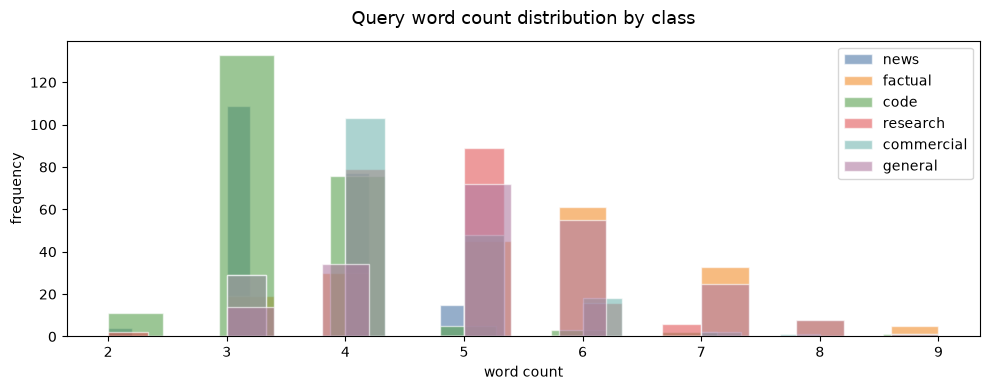

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
for i, intent in enumerate(INTENT_CLASSES):
    subset = df[df['intent'] == intent]['query_length']
    ax.hist(subset, bins=15, alpha=0.6, label=intent, color=colors[i], edgecolor='white')
ax.set_title('Query word count distribution by class', fontsize=13, pad=12)
ax.set_xlabel('word count')
ax.set_ylabel('frequency')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Spot-check: sample 5 queries per class

In [9]:
print('Sample queries per class (verify labels look correct):\n')
for intent in INTENT_CLASSES:
    samples = df[df['intent'] == intent]['query'].sample(5, random_state=RANDOM_SEED).tolist()
    print(f'{intent.upper()}')
    for s in samples:
        print(f'  {s}')
    print()

Sample queries per class (verify labels look correct):

NEWS
  apple earnings report this quarter
  weather forecast tomorrow
  Meta earnings today
  rugby championship result africa
  disease outbreak news

FACTUAL
  what is M-Pesa
  what is the atomic number of gold
  how many bones in the human body
  what is equity bank paybill number
  how many moons does mars have

CODE
  split io go
  pip install local package
  postgres index types
  python struct pack unpack
  how to reverse a string in python

RESEARCH
  overview of autoML
  explain gradient accumulation
  how does beam search work
  overview of discourse analysis
  how does the TCP handshake work

COMMERCIAL
  best satellite TV provider kenya
  best SSD for laptop upgrade
  top headphones for remote work calls
  recommended invoicing software freelancer
  top POS system kenya

GENERAL
  how to make chapati
  herbal remedies nairobi
  how to preserve avocados
  tips for greenhouse farming
  how to plan a wedding on a budget



## 6. Stratified train / val / test split

Split is stratified so each class appears in each split at the same proportion.
Ratio: 80% train, 10% val, 10% test.

The test split is held out completely. Do not inspect test examples until
all hyperparameter decisions are finalised in notebook 02.

In [10]:
train_df, temp_df = train_test_split(
    df[['query', 'intent']],
    test_size=0.20,
    stratify=df['intent'],
    random_state=RANDOM_SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['intent'],
    random_state=RANDOM_SEED
)

print(f'train: {len(train_df)} examples')
print(f'val: {len(val_df)} examples')
print(f'test: {len(test_df)} examples')
print(f'total: {len(train_df) + len(val_df) + len(test_df)} (matches {len(df)}: {len(train_df) + len(val_df) + len(test_df) == len(df)})')

train: 1014 examples
val: 127 examples
test: 127 examples
total: 1268 (matches 1268: True)


In [11]:
print('Class distribution in each split:')
split_counts = pd.DataFrame({
    'train': train_df['intent'].value_counts().reindex(INTENT_CLASSES),
    'val': val_df['intent'].value_counts().reindex(INTENT_CLASSES),
    'test': test_df['intent'].value_counts().reindex(INTENT_CLASSES),
})
print(split_counts.to_string())

Class distribution in each split:
            train  val  test
intent                      
news          164   21    20
factual       161   20    20
code          184   23    24
research      177   22    22
commercial    161   20    20
general       167   21    21


## 7. Write splits to disk

In [12]:
train_df.to_csv(PROC_DIR / 'train.csv', index=False)
val_df.to_csv(PROC_DIR / 'val.csv', index=False)
test_df.to_csv(PROC_DIR / 'test.csv', index=False)

print(f'Written to {PROC_DIR}:')
for f in sorted(PROC_DIR.iterdir()):
    print(f'{f.name} ({f.stat().st_size} bytes)')

Written to ../data/processed:
test.csv (4535 bytes)
train.csv (36462 bytes)
val.csv (4409 bytes)


## 8. Final gate

All cells above must run without errors before proceeding to notebook 02.

In [ ]:
checks = {
    'no null values': df.isnull().sum().sum() == 0,
    'no unknown classes': len(set(df['intent'].unique()) - set(INTENT_CLASSES)) == 0,
    'no duplicate queries': df.duplicated(subset=['query']).sum() == 0,
    'all classes meet minimum': all(counts >= MIN_PER_CLASS),
    'splits sum to total': len(train_df) + len(val_df) + len(test_df) == len(df),
    'all three splits written': all((PROC_DIR / f).exists() for f in ['train.csv', 'val.csv', 'test.csv']),
}

all_passed = True
for check, result in checks.items():
    status = 'PASS' if result else 'FAIL'
    print(f'{status} {check}')
    if not result:
        all_passed = False

print()
if all_passed:
    print('All checks passed. Proceed to 02_fine_tune_classifier.ipynb.')
else:
    raise ValueError('One or more checks failed. Fix before proceeding.')

PASS no null values
PASS no unknown classes
PASS no duplicate queries
PASS all classes meet minimum
PASS splits sum to total
PASS all three splits written

All checks passed. Proceed to 02_fine_tune_classifier.ipynb.


: 